# Lesson 4: Simulation, Data Preparation, and Time-Series Analysis

**Probability, Statistics, and Econometrics for Finance, Accounting, and Economics**  
Campbell University — Lundy-Fetterman School of Business  
Matthew L. Kelly, PhD

## Where this lecture fits in the 7-lecture sequence

1. **Probability distributions and descriptive statistics**  
2. **Hypothesis testing and experimental design**  
3. **Relationships between variables: covariance, correlation, dependence, and regression**  
4. **Simulation, data preparation, and time-series analysis**  
5. Regression and causal interpretation  
6. Forecasting, risk, and model evaluation  
7. Applied econometric projects in finance, accounting, and economics

This lecture turns the tools from the first three lessons into dynamic models. We move from isolated observations to ordered observations: stock prices through time, interest rates through time, macroeconomic aggregates through time, and portfolio returns through time.

The central question is: **when observations arrive in time order, what changes about statistical reasoning?**

## Learning objectives

By the end of this notebook, you should be able to:

1. Explain the independent and identically distributed, or i.i.d., assumption.
2. Simulate common stochastic processes used in finance and economics.
3. Distinguish stationary from non-stationary time series.
4. Use transformations such as differencing and logs to prepare time-series data.
5. Estimate basic autoregressive and ARIMA models.
6. Interpret autocorrelation, partial autocorrelation, and residual diagnostics.
7. Simulate time-varying volatility and calculate Value at Risk.
8. Fit and interpret a simple vector autoregression.

## 0. Setup

This notebook uses standard scientific Python libraries. The examples avoid fragile external dependencies such as `prophet`, `tensorflow`, or the separate `arch` package so the file can run from top to bottom in a basic Python environment.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.signal import detrend
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.api import VAR

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

# 1. The i.i.d. benchmark and why time series are different

Many statistical tools begin with an i.i.d. assumption. A sequence $X_1, X_2, \ldots, X_n$ is **independent and identically distributed** if:

$$
X_i \sim F \quad \text{for all } i
$$

and

$$
P(X_1 \leq x_1,\ldots, X_n \leq x_n)
= \prod_{i=1}^n P(X_i \leq x_i).
$$

The first condition says every observation comes from the same distribution. The second says observations do not statistically depend on one another.

Financial and macroeconomic time series often violate both assumptions. Stock prices may trend, inflation regimes may shift, and volatility may cluster. That is why time-series analysis requires its own tools.

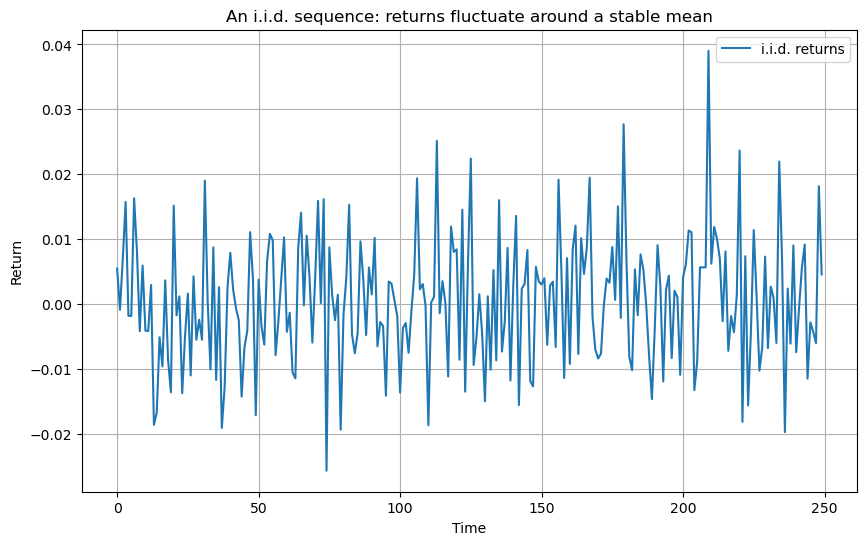

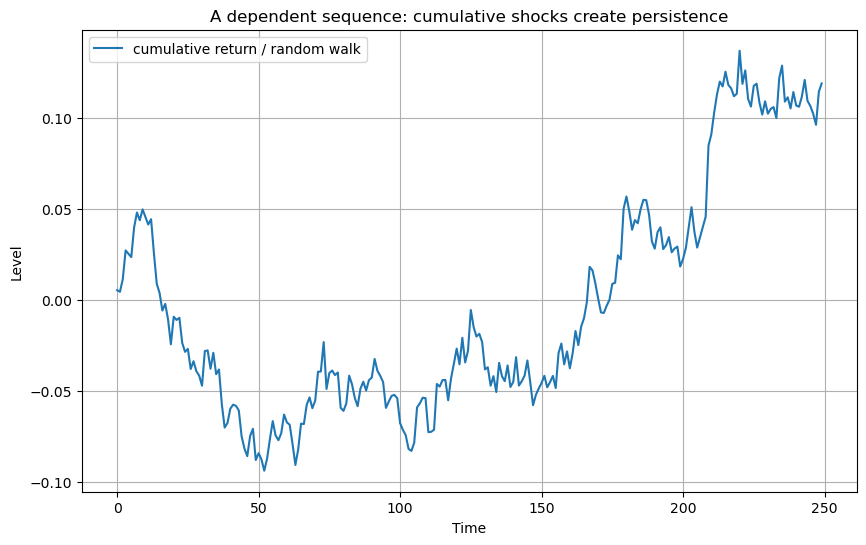

In [3]:
# Compare i.i.d. data with a dependent time series.
n = 250

iid_returns = np.random.normal(loc=0.0005, scale=0.01, size=n)
random_walk = np.cumsum(iid_returns)

plt.figure()
plt.plot(iid_returns, label="i.i.d. returns")
plt.title("An i.i.d. sequence: returns fluctuate around a stable mean")
plt.xlabel("Time")
plt.ylabel("Return")
plt.legend()
plt.show()

plt.figure()
plt.plot(random_walk, label="cumulative return / random walk")
plt.title("A dependent sequence: cumulative shocks create persistence")
plt.xlabel("Time")
plt.ylabel("Level")
plt.legend()
plt.show()

# 2. Simulating stochastic processes

Simulation lets us create data when the data-generating process is known. This is useful because it gives us a laboratory in which the true model is known before we estimate anything.

A simulation usually follows four steps:

1. Specify the model.
2. Choose parameters.
3. Draw random shocks.
4. Study the simulated outcomes.

## 2.1 Brownian motion and geometric Brownian motion

A standard Brownian motion, or Wiener process, $W_t$ has normally distributed increments:

$$
W_{t+\Delta t} - W_t \sim N(0, \Delta t).
$$

A common model for a stock price is **geometric Brownian motion**:

$$
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t.
$$

The exact solution is:

$$
S_t = S_0 \exp\left[\left(\mu - \frac{1}{2}\sigma^2\right)t + \sigma W_t\right].
$$

Here $\mu$ is the drift, $\sigma$ is volatility, and $W_t$ is Brownian motion.

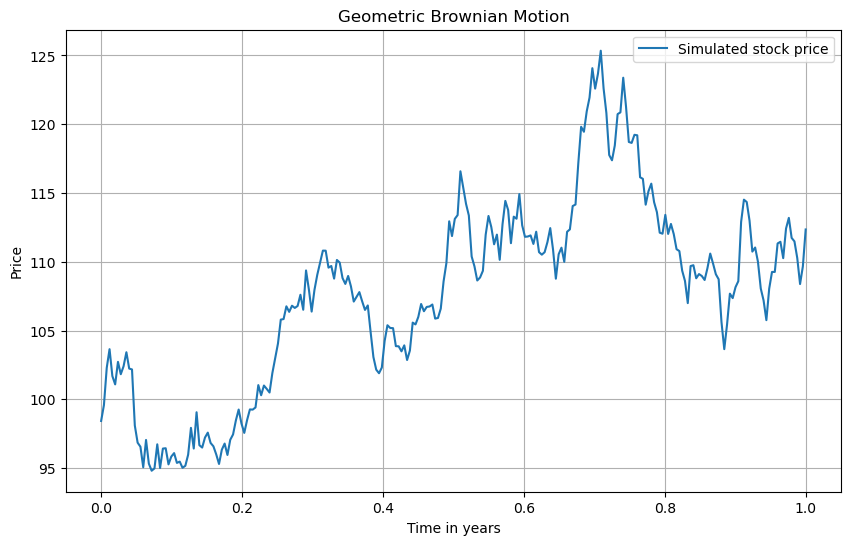

In [5]:
T = 1.0          # one year
N = 252          # trading days
dt = T / N
mu = 0.05
sigma = 0.20
S0 = 100

time = np.linspace(0, T, N)
W = np.random.normal(0, np.sqrt(dt), N).cumsum()
S = S0 * np.exp((mu - 0.5 * sigma**2) * time + sigma * W)

plt.figure()
plt.plot(time, S, label="Simulated stock price")
plt.title("Geometric Brownian Motion")
plt.xlabel("Time in years")
plt.ylabel("Price")
plt.legend()
plt.show()

## 2.2 Binomial outcomes: defaults, successes, and failures

A binomial random variable counts the number of successes in $n$ independent trials, each with success probability $p$:

$$
X \sim \operatorname{Binomial}(n,p).
$$

Its probability mass function is:

$$
P(X=k) = {n \choose k}p^k(1-p)^{n-k}.
$$

In finance, a simplified example is the number of defaults in a loan pool.

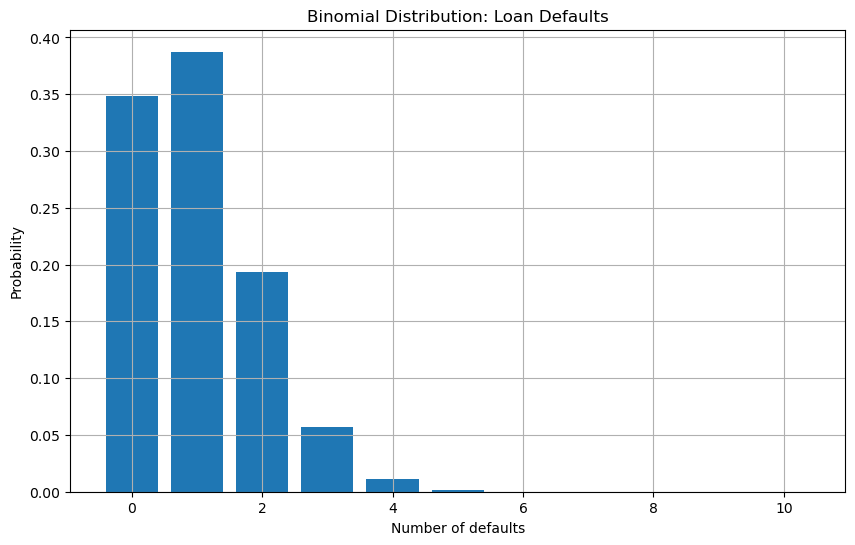

Expected number of defaults: 1.00


In [7]:
n_loans = 10
p_default = 0.10
x = np.arange(0, n_loans + 1)
probabilities = stats.binom.pmf(x, n_loans, p_default)

plt.figure()
plt.bar(x, probabilities)
plt.title("Binomial Distribution: Loan Defaults")
plt.xlabel("Number of defaults")
plt.ylabel("Probability")
plt.show()

expected_defaults = n_loans * p_default
print(f"Expected number of defaults: {expected_defaults:.2f}")

## 2.3 Monte Carlo simulation for portfolio returns

Suppose a portfolio has weights $w$ and random asset returns $R$. The portfolio return is:

$$
R_p = w'R.
$$

If returns are jointly normal,

$$
R \sim N(\mu, \Sigma),
$$

then many possible portfolio returns can be simulated from the mean vector $\mu$ and covariance matrix $\Sigma$.

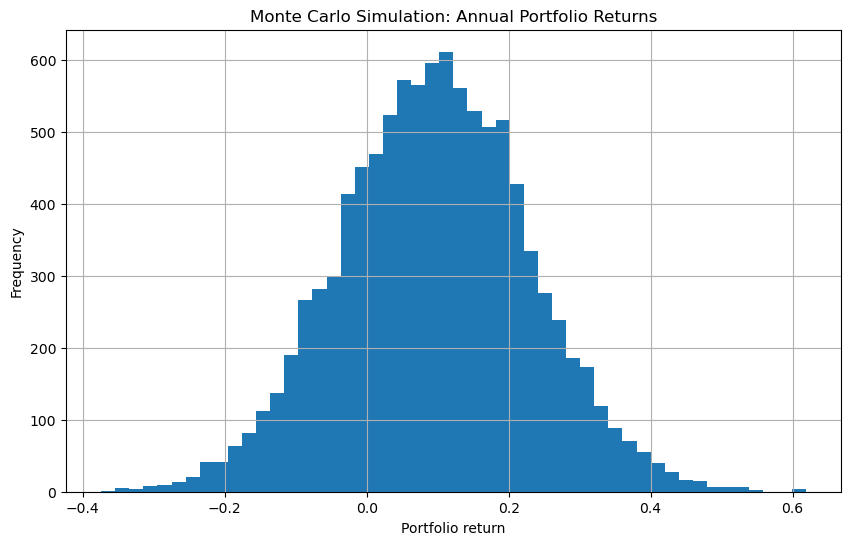

Expected simulated portfolio return: 9.59%
Simulated portfolio standard deviation: 13.34%


In [9]:
num_simulations = 10_000
weights = np.array([0.60, 0.40])
mean_returns = np.array([0.08, 0.12])
cov_matrix = np.array([
    [0.10**2, 0.02],
    [0.02, 0.15**2]
])

simulated_asset_returns = np.random.multivariate_normal(
    mean_returns, cov_matrix, size=num_simulations
)
portfolio_returns = simulated_asset_returns @ weights

plt.figure()
plt.hist(portfolio_returns, bins=50)
plt.title("Monte Carlo Simulation: Annual Portfolio Returns")
plt.xlabel("Portfolio return")
plt.ylabel("Frequency")
plt.show()

print(f"Expected simulated portfolio return: {portfolio_returns.mean():.2%}")
print(f"Simulated portfolio standard deviation: {portfolio_returns.std(ddof=1):.2%}")

## 2.4 Mean reversion and the Ornstein--Uhlenbeck process

Some economic and financial variables are modeled as mean-reverting. Examples include interest rates, credit spreads, valuation ratios, and deviations from long-run equilibrium.

A continuous-time mean-reverting process is the **Ornstein--Uhlenbeck process**:

$$
dX_t = \theta(\mu - X_t)\,dt + \sigma\,dW_t.
$$

Here $\mu$ is the long-run mean, $\theta$ is the speed of mean reversion, and $\sigma$ is volatility.

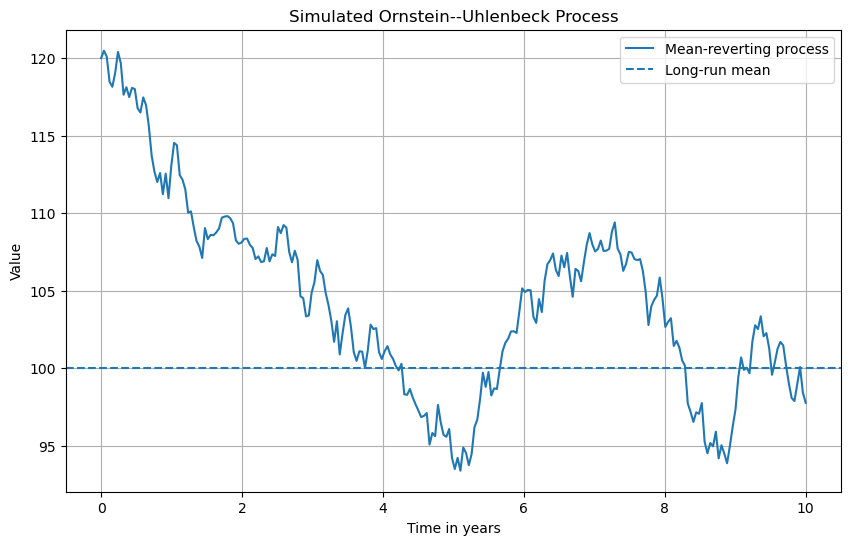

In [11]:
T = 10.0
N = 252
dt = T / N
theta = 0.50
long_run_mean = 100
sigma = 5
X0 = 120

time = np.linspace(0, T, N)
X = np.zeros(N)
X[0] = X0

for t in range(1, N):
    X[t] = X[t-1] + theta * (long_run_mean - X[t-1]) * dt + sigma * np.sqrt(dt) * np.random.normal()

plt.figure()
plt.plot(time, X, label="Mean-reverting process")
plt.axhline(long_run_mean, linestyle="--", label="Long-run mean")
plt.title("Simulated Ornstein--Uhlenbeck Process")
plt.xlabel("Time in years")
plt.ylabel("Value")
plt.legend()
plt.show()

# 3. Stationarity and data preparation

A time series is **weakly stationary** if its mean, variance, and autocovariance do not change over time:

$$
E[X_t] = \mu,
$$

$$
\operatorname{Var}(X_t)=\sigma^2,
$$

and

$$
\operatorname{Cov}(X_t, X_{t-k}) = \gamma_k.
$$

The autocovariance may depend on the lag $k$, but not on calendar time $t$.

## 3.1 ADF and KPSS tests

The **Augmented Dickey--Fuller test** has a unit-root null hypothesis:

$$
H_0: \text{the series has a unit root and is non-stationary.}
$$

The **KPSS test** reverses the null:

$$
H_0: \text{the series is stationary around a constant or trend.}
$$

Because their null hypotheses differ, it is often useful to examine both tests together.

In [13]:
def summarize_stationarity(series, name):
    series = pd.Series(series).dropna()
    adf_stat, adf_pvalue, *_ = adfuller(series)
    kpss_stat, kpss_pvalue, *_ = kpss(series, regression="c", nlags="auto")
    print(f"{name}")
    print("-" * len(name))
    print(f"ADF statistic:  {adf_stat: .4f}; p-value: {adf_pvalue: .4f}")
    print(f"KPSS statistic: {kpss_stat: .4f}; p-value: {kpss_pvalue: .4f}")
    print()

n = 250
white_noise = np.random.normal(0, 1, n)
random_walk = np.cumsum(np.random.normal(0, 1, n))

summarize_stationarity(white_noise, "White noise")
summarize_stationarity(random_walk, "Random walk")

White noise
-----------
ADF statistic:  -12.3571; p-value:  0.0000
KPSS statistic:  0.3448; p-value:  0.1000

Random walk
-----------
ADF statistic:  -2.3778; p-value:  0.1481
KPSS statistic:  1.0865; p-value:  0.0100



C:\Users\mlkelly0906\AppData\Local\Temp\ipykernel_31172\4225221516.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(series, regression="c", nlags="auto")
C:\Users\mlkelly0906\AppData\Local\Temp\ipykernel_31172\4225221516.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(series, regression="c", nlags="auto")


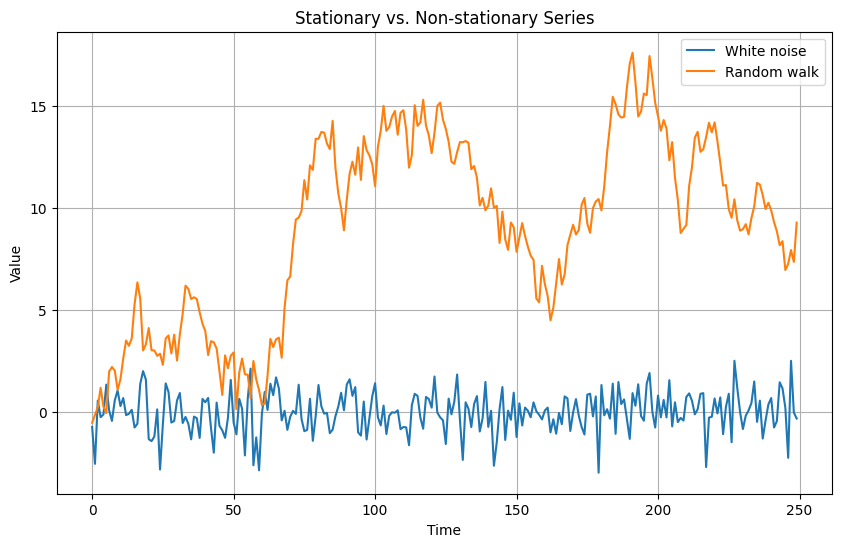

In [8]:
plt.figure()
plt.plot(white_noise, label="White noise")
plt.plot(random_walk, label="Random walk")
plt.title("Stationary vs. Non-stationary Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

## 3.2 Differencing

A common way to transform a non-stationary series is first differencing:

$$
\Delta X_t = X_t - X_{t-1}.
$$

If $X_t$ is a random walk,

$$
X_t = X_{t-1} + \varepsilon_t,
$$

then the first difference is simply:

$$
\Delta X_t = \varepsilon_t.
$$

/tmp/ipykernel_5517/4225221516.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(series, regression="c", nlags="auto")


First difference of random walk
-------------------------------
ADF statistic:  -15.8967; p-value:  0.0000
KPSS statistic:  0.1614; p-value:  0.1000



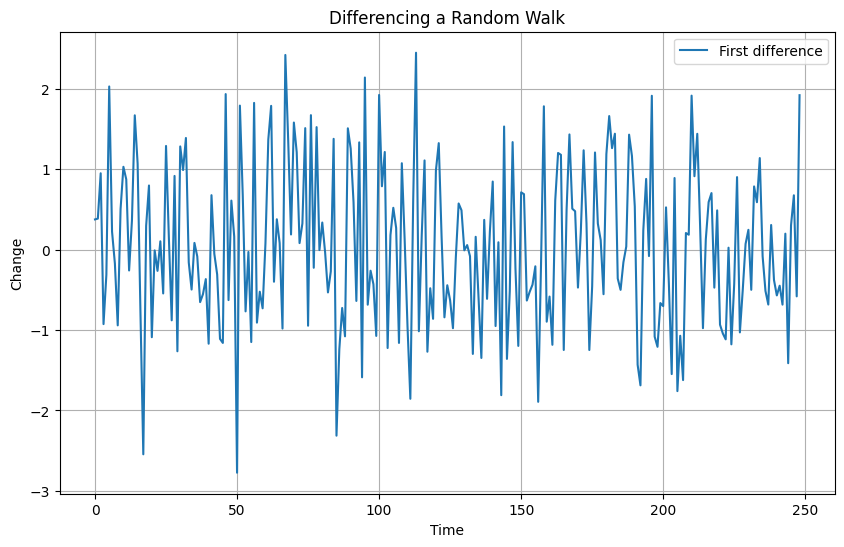

In [9]:
differenced_random_walk = np.diff(random_walk)

summarize_stationarity(differenced_random_walk, "First difference of random walk")

plt.figure()
plt.plot(differenced_random_walk, label="First difference")
plt.title("Differencing a Random Walk")
plt.xlabel("Time")
plt.ylabel("Change")
plt.legend()
plt.show()

## 3.3 Logs and log differences

For a positive series $P_t$, the log transformation is often useful:

$$
p_t = \log(P_t).
$$

The log difference approximates a growth rate:

$$
\Delta \log(P_t) = \log(P_t) - \log(P_{t-1}) \approx \frac{P_t - P_{t-1}}{P_{t-1}}.
$$

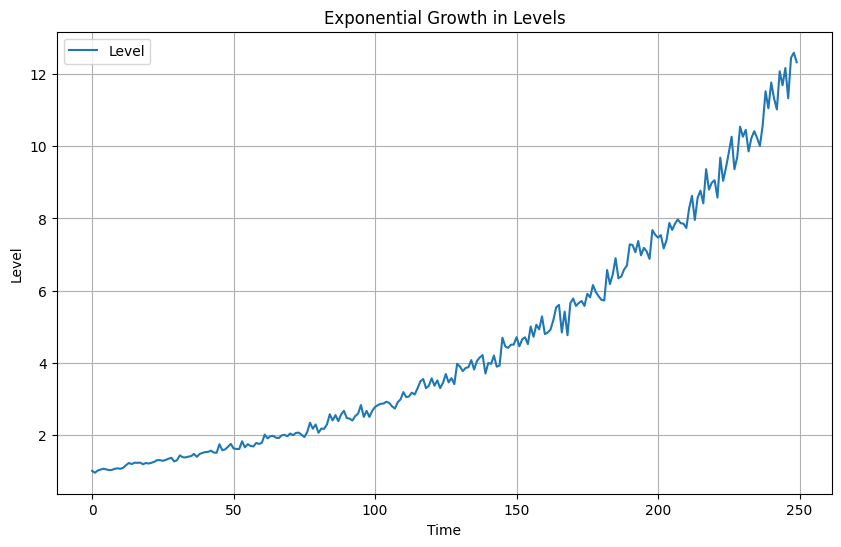

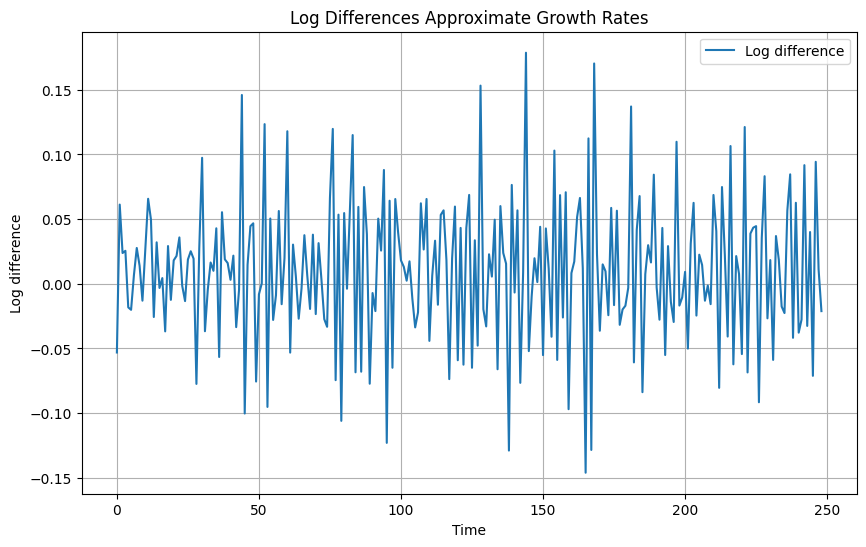

In [10]:
time_index = np.arange(1, n + 1)
level_series = np.exp(0.01 * time_index) * np.random.lognormal(mean=0, sigma=0.04, size=n)
log_series = np.log(level_series)
log_diff = np.diff(log_series)

plt.figure()
plt.plot(level_series, label="Level")
plt.title("Exponential Growth in Levels")
plt.xlabel("Time")
plt.ylabel("Level")
plt.legend()
plt.show()

plt.figure()
plt.plot(log_diff, label="Log difference")
plt.title("Log Differences Approximate Growth Rates")
plt.xlabel("Time")
plt.ylabel("Log difference")
plt.legend()
plt.show()

## 3.4 Detrending and seasonal decomposition

If a series has a deterministic trend, one option is to remove the fitted trend. If a series has repeated seasonal movements, decomposition can separate observed data into components:

$$
Y_t = T_t + S_t + e_t,
$$

where $T_t$ is trend, $S_t$ is seasonality, and $e_t$ is the residual.

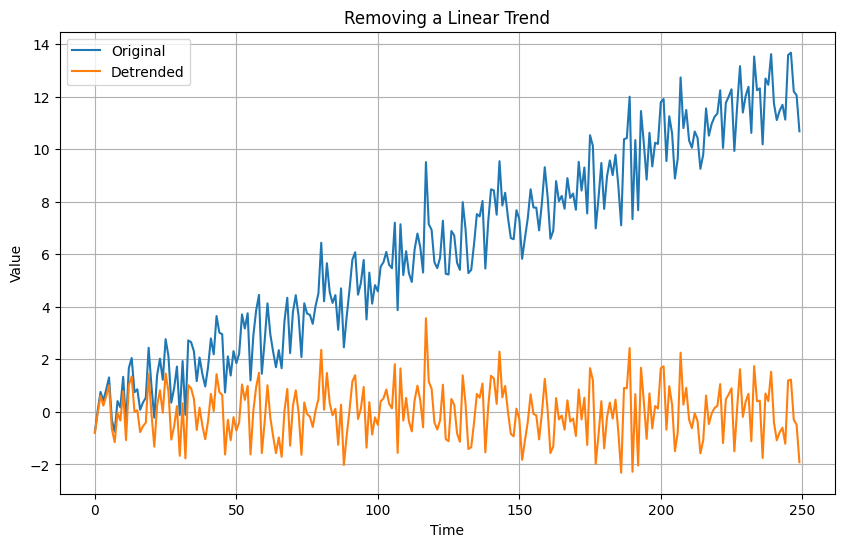

In [11]:
trend_plus_noise = 0.05 * time_index + np.random.normal(0, 1, n)
detrended = detrend(trend_plus_noise)

plt.figure()
plt.plot(trend_plus_noise, label="Original")
plt.plot(detrended, label="Detrended")
plt.title("Removing a Linear Trend")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

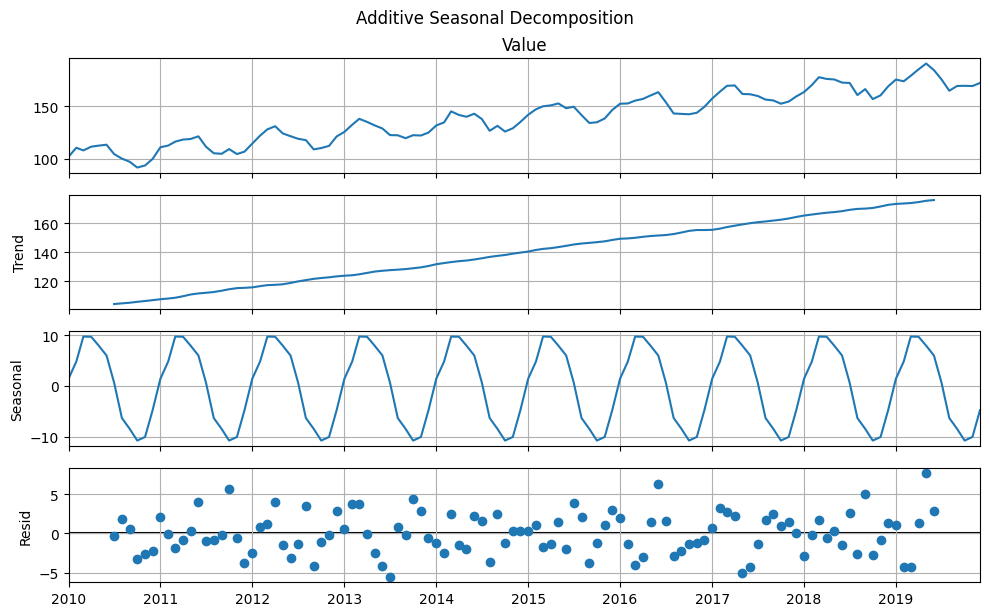

In [12]:
months = pd.date_range("2010-01-01", periods=120, freq="MS")
trend = np.linspace(100, 180, len(months))
seasonal = 10 * np.sin(2 * np.pi * np.arange(len(months)) / 12)
noise = np.random.normal(0, 3, len(months))
monthly_series = pd.Series(trend + seasonal + noise, index=months, name="Value")

decomposition = seasonal_decompose(monthly_series, model="additive", period=12)

decomposition.plot()
plt.suptitle("Additive Seasonal Decomposition", y=1.02)
plt.show()

# 4. Autocorrelation and simple time-series models

The autocorrelation at lag $k$ is:

$$
\rho_k = \frac{\operatorname{Cov}(X_t, X_{t-k})}{\operatorname{Var}(X_t)}.
$$

Autocorrelation is one of the main reasons time series cannot usually be treated as ordinary i.i.d. samples.

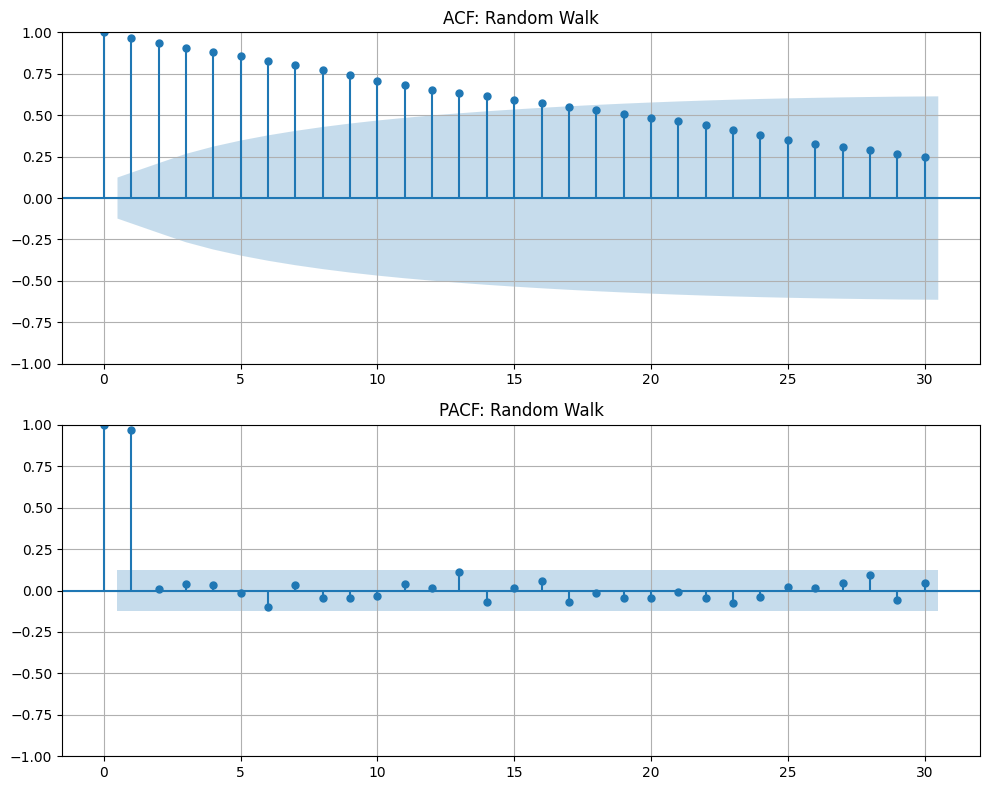

        lb_stat  lb_pvalue
10  1832.185157        0.0


In [13]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(random_walk, lags=30, ax=axes[0])
axes[0].set_title("ACF: Random Walk")
plot_pacf(random_walk, lags=30, ax=axes[1], method="ywm")
axes[1].set_title("PACF: Random Walk")
plt.tight_layout()
plt.show()

lb_result = acorr_ljungbox(random_walk, lags=[10], return_df=True)
print(lb_result)

## 4.1 Autoregressive models

An autoregressive model of order one, or AR(1), is:

$$
X_t = c + \phi X_{t-1} + \varepsilon_t.
$$

If $|\phi|<1$, the process is stationary. If $\phi=1$, the process has a unit root and behaves like a random walk.

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  300
Model:                     AutoReg(1)   Log Likelihood                -403.852
Method:               Conditional MLE   S.D. of innovations              0.934
Date:                Thu, 14 May 2026   AIC                            813.703
Time:                        03:59:49   BIC                            824.804
Sample:                             1   HQIC                           818.146
                                  300                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0267      0.054      0.492      0.623      -0.080       0.133
y.L1           0.8271      0.033     25.285      0.000       0.763       0.891
                                    Roots           

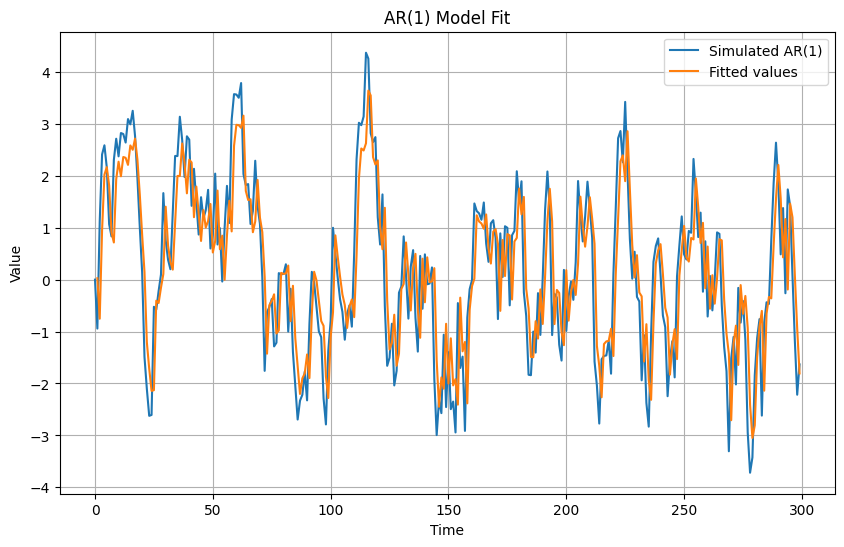

In [14]:
n = 300
phi = 0.80
errors = np.random.normal(0, 1, n)
ar1 = np.zeros(n)

for t in range(1, n):
    ar1[t] = phi * ar1[t-1] + errors[t]

ar_model = AutoReg(ar1, lags=1, old_names=False).fit()
print(ar_model.summary())

plt.figure()
plt.plot(ar1, label="Simulated AR(1)")
plt.plot(np.arange(1, n), ar_model.fittedvalues, label="Fitted values")
plt.title("AR(1) Model Fit")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

## 4.2 ARIMA models

An ARIMA model is indexed by $(p,d,q)$:

- $p$: autoregressive lags,
- $d$: number of differences,
- $q$: moving-average lags.

The integrated part says that the model is fit after differencing the series $d$ times. A simple example is ARIMA$(1,1,1)$.

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  300
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -422.818
Date:                Thu, 14 May 2026   AIC                            851.637
Time:                        03:59:50   BIC                            862.738
Sample:                             0   HQIC                           856.080
                                - 300                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.002    417.207      0.000       0.995       1.005
ma.L1         -0.9994      0.121     -8.233      0.000      -1.237      -0.761
sigma2         0.9834      0.134      7.339      0.0

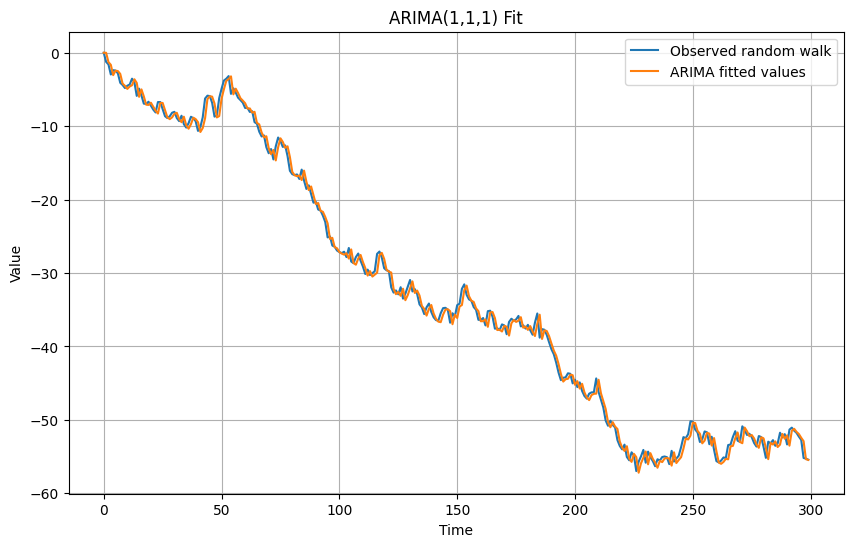

In [15]:
random_walk_for_arima = np.cumsum(np.random.normal(0, 1, n))

arima_model = ARIMA(random_walk_for_arima, order=(1, 1, 1)).fit()
print(arima_model.summary())

plt.figure()
plt.plot(random_walk_for_arima, label="Observed random walk")
plt.plot(arima_model.fittedvalues, label="ARIMA fitted values")
plt.title("ARIMA(1,1,1) Fit")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

## 4.3 Forecasting a seasonal series with Holt--Winters smoothing

A seasonal time-series model can be written schematically as:

$$
Y_t = \ell_t + b_t + s_t + \varepsilon_t,
$$

where $\ell_t$ is the level, $b_t$ is the trend, and $s_t$ is the seasonal component.

Holt--Winters exponential smoothing updates these components recursively and is useful for forecasting when trend and seasonality are visible.

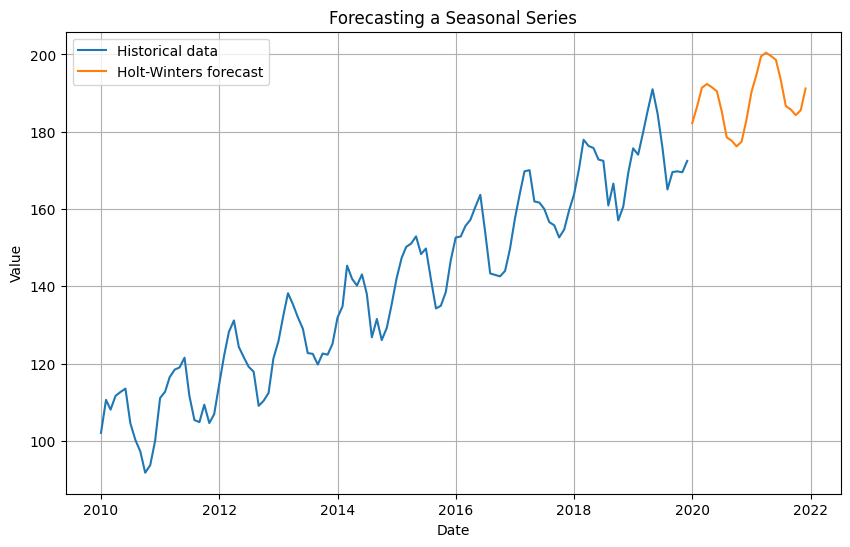

In [16]:
seasonal_series = monthly_series.copy()
hw_model = ExponentialSmoothing(
    seasonal_series,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
).fit()

forecast_steps = 24
hw_forecast = hw_model.forecast(forecast_steps)

plt.figure()
plt.plot(seasonal_series, label="Historical data")
plt.plot(hw_forecast, label="Holt-Winters forecast")
plt.title("Forecasting a Seasonal Series")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.show()

# 5. Volatility, GARCH intuition, and risk measures

A key feature of financial returns is **volatility clustering**: large absolute returns tend to be followed by large absolute returns, and small absolute returns tend to be followed by small absolute returns.

A GARCH$(1,1)$ variance equation is:

$$
\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2.
$$

The parameter $\alpha$ captures the immediate effect of recent shocks. The parameter $\beta$ captures volatility persistence.

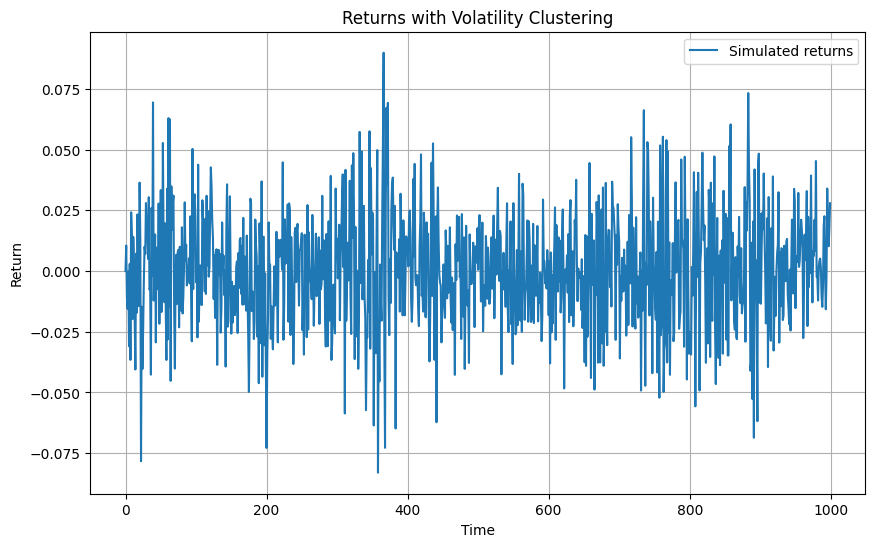

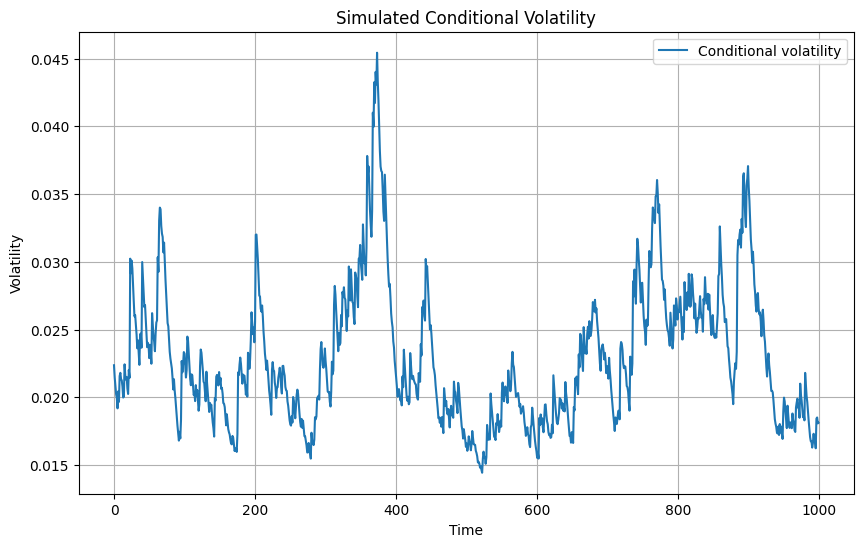

ARCH LM statistic: 92.5877
ARCH LM p-value:   0.0000


In [17]:
n = 1_000
omega = 0.00001
alpha = 0.08
beta = 0.90

conditional_variance = np.zeros(n)
returns = np.zeros(n)
conditional_variance[0] = omega / (1 - alpha - beta)

for t in range(1, n):
    conditional_variance[t] = omega + alpha * returns[t-1]**2 + beta * conditional_variance[t-1]
    returns[t] = np.sqrt(conditional_variance[t]) * np.random.normal()

conditional_volatility = np.sqrt(conditional_variance)

plt.figure()
plt.plot(returns, label="Simulated returns")
plt.title("Returns with Volatility Clustering")
plt.xlabel("Time")
plt.ylabel("Return")
plt.legend()
plt.show()

plt.figure()
plt.plot(conditional_volatility, label="Conditional volatility")
plt.title("Simulated Conditional Volatility")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.show()

arch_lm = het_arch(returns)
print(f"ARCH LM statistic: {arch_lm[0]:.4f}")
print(f"ARCH LM p-value:   {arch_lm[1]:.4f}")

## 5.1 Value at Risk and Conditional Value at Risk

For a return distribution, the $q$-level Value at Risk is a lower-tail quantile:

$$
\operatorname{VaR}_{q} = F_R^{-1}(q).
$$

For a 95% confidence level, we often use the 5th percentile of returns. The corresponding Conditional Value at Risk, also called Expected Shortfall, is:

$$
\operatorname{CVaR}_{q} = E[R \mid R \leq \operatorname{VaR}_q].
$$

VaR answers: **how bad is the cutoff loss?**  
CVaR answers: **how bad are losses once we are beyond the cutoff?**

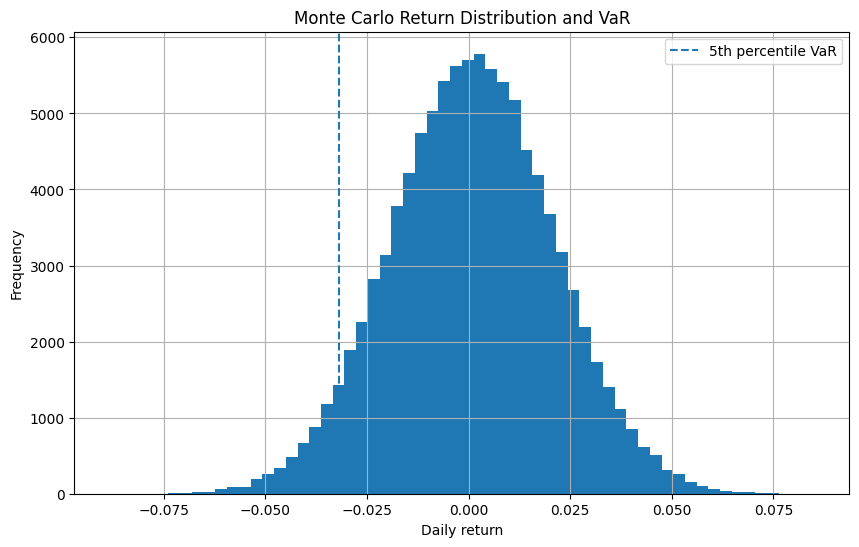

VaR at 95% confidence:  -3.19%
CVaR at 95% confidence: -4.03%


In [18]:
mean_daily_return = 0.001
vol_daily_return = 0.02
simulations = 100_000

simulated_daily_returns = np.random.normal(mean_daily_return, vol_daily_return, simulations)
var_95 = np.percentile(simulated_daily_returns, 5)
cvar_95 = simulated_daily_returns[simulated_daily_returns <= var_95].mean()

plt.figure()
plt.hist(simulated_daily_returns, bins=60)
plt.axvline(var_95, linestyle="--", label="5th percentile VaR")
plt.title("Monte Carlo Return Distribution and VaR")
plt.xlabel("Daily return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print(f"VaR at 95% confidence:  {var_95:.2%}")
print(f"CVaR at 95% confidence: {cvar_95:.2%}")

# 6. Vector autoregressions

Many economic questions involve more than one time series. A vector autoregression, or VAR, treats each variable as a function of its own lags and the lags of the other variables.

For a two-variable VAR$(1)$:

$$
\begin{bmatrix}
y_{1t} \\
y_{2t}
\end{bmatrix}
=
\begin{bmatrix}
c_1 \\
c_2
\end{bmatrix}
+
A_1
\begin{bmatrix}
y_{1,t-1} \\
y_{2,t-1}
\end{bmatrix}
+
\begin{bmatrix}
\varepsilon_{1t} \\
\varepsilon_{2t}
\end{bmatrix}.
$$

VAR models are common in macroeconomics because they represent dynamic feedback between variables such as GDP growth, inflation, interest rates, and money growth.

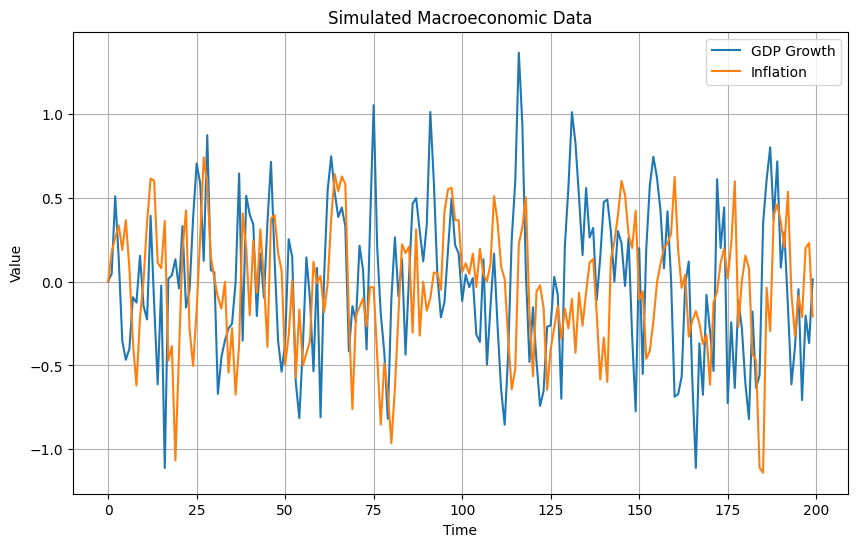

In [19]:
n = 200
shock_1 = np.random.normal(0, 0.4, n)
shock_2 = np.random.normal(0, 0.3, n)

gdp_growth = np.zeros(n)
inflation = np.zeros(n)

for t in range(1, n):
    gdp_growth[t] = 0.50 * gdp_growth[t-1] - 0.20 * inflation[t-1] + shock_1[t]
    inflation[t] = 0.25 * gdp_growth[t-1] + 0.60 * inflation[t-1] + shock_2[t]

macro_data = pd.DataFrame({
    "GDP Growth": gdp_growth,
    "Inflation": inflation,
})

macro_data.plot(title="Simulated Macroeconomic Data")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

In [20]:
var_model = VAR(macro_data)
lag_order_results = var_model.select_order(maxlags=6)
print(lag_order_results.summary())

fitted_var = var_model.fit(maxlags=2)
print(fitted_var.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -3.554      -3.520     0.02861      -3.540
1     -4.324*     -4.223*    0.01324*     -4.283*
2      -4.297      -4.129     0.01360      -4.229
3      -4.281      -4.045     0.01383      -4.186
4      -4.247      -3.944     0.01431      -4.124
5      -4.229      -3.858     0.01457      -4.079
6      -4.202      -3.764     0.01497      -4.025
-------------------------------------------------
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 14, May, 2026
Time:                     03:59:51
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -4.14768
Nobs:                     198.000    HQIC:                  -4.24653
Log likelihood:          -124.838    FPE:                  0.0133835

## 6.1 Impulse responses and Granger causality

An impulse response traces the effect of a one-time shock to one variable on the future path of all variables in the system.

Granger causality is a predictive concept. Variable $x$ Granger-causes variable $y$ when lagged values of $x$ help forecast $y$ after controlling for lagged values of $y$.

It is not the same as structural causality, but it is a useful forecasting diagnostic.

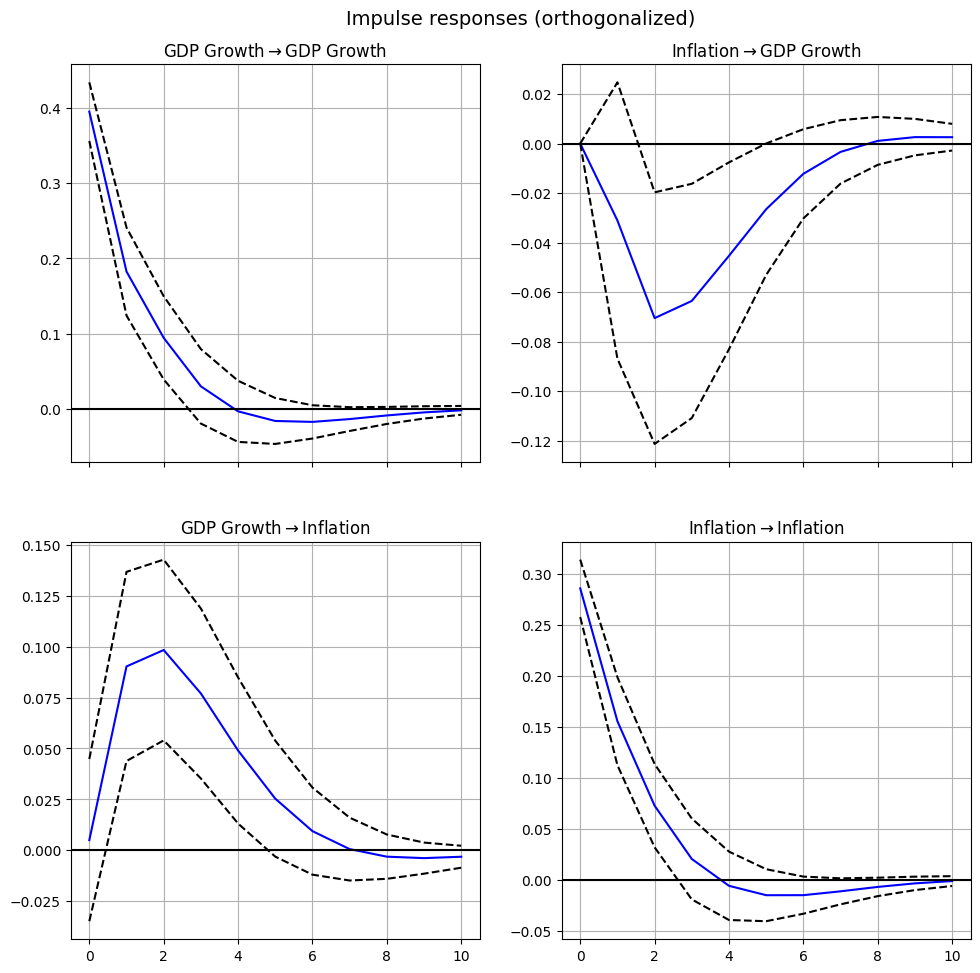

Granger causality F-test. H_0: GDP Growth does not Granger-cause Inflation. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
         12.99          3.019   0.000 (2, 386)
----------------------------------------------
   GDP Growth  Inflation
0   -0.032307  -0.141696
1    0.018703  -0.099538
2    0.026303  -0.067466
3    0.023205  -0.047931
4    0.015644  -0.038380
5    0.008262  -0.035272
6    0.002800  -0.035553
7   -0.000511  -0.037138


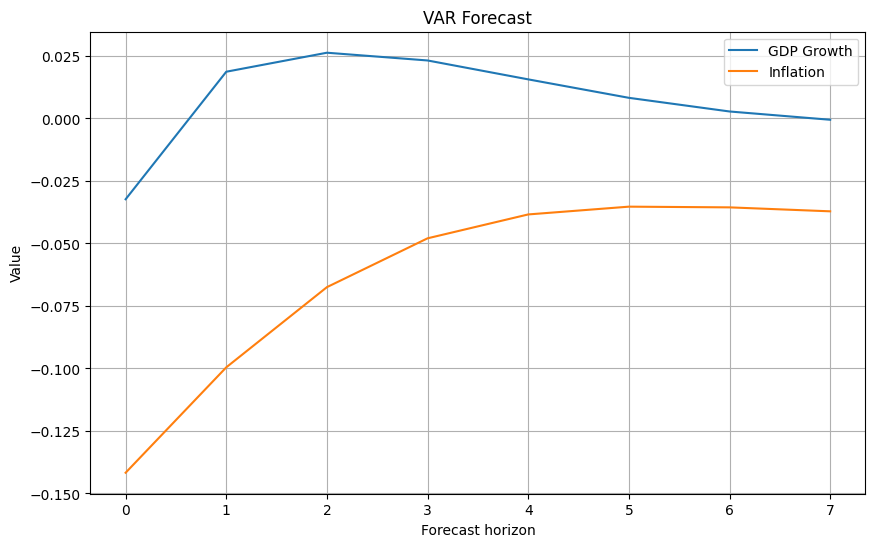

In [21]:
irf = fitted_var.irf(10)
irf.plot(orth=True)
plt.show()

granger_result = fitted_var.test_causality("Inflation", ["GDP Growth"], kind="f")
print(granger_result.summary())

forecast = fitted_var.forecast(macro_data.values[-fitted_var.k_ar:], steps=8)
forecast_df = pd.DataFrame(forecast, columns=macro_data.columns)
print(forecast_df)

forecast_df.plot(title="VAR Forecast")
plt.xlabel("Forecast horizon")
plt.ylabel("Value")
plt.show()

# 7. Residual diagnostics

A time-series model should not merely fit the observed series. Its residuals should also behave reasonably.

For many models, the residuals should look approximately like white noise:

$$
E[\varepsilon_t]=0,
$$

$$
\operatorname{Cov}(\varepsilon_t,\varepsilon_{t-k})=0 \quad \text{for } k \neq 0.
$$

Residual autocorrelation means the model has failed to capture some predictable structure.

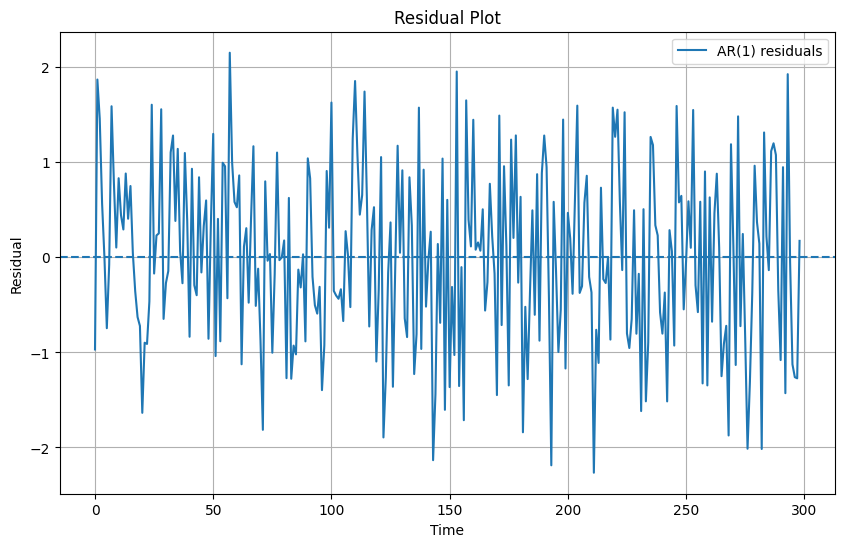

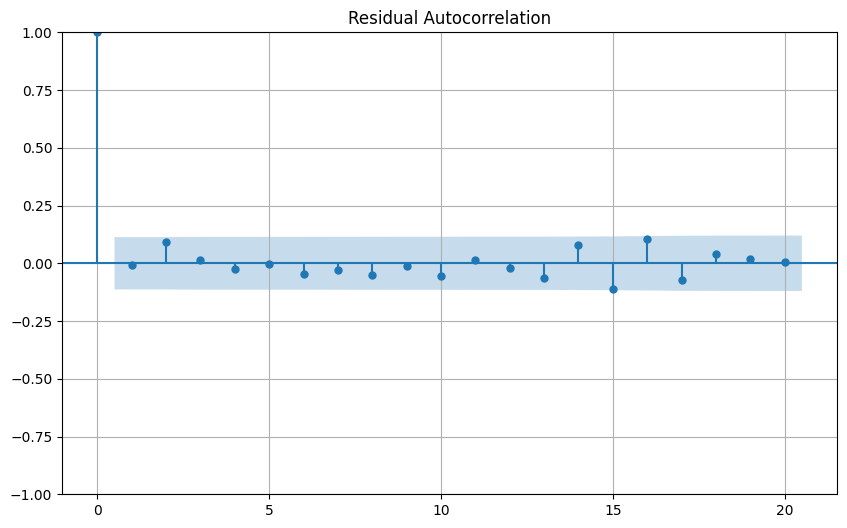

     lb_stat  lb_pvalue
10  5.418894   0.861499


In [22]:
residuals = ar_model.resid

plt.figure()
plt.plot(residuals, label="AR(1) residuals")
plt.axhline(0, linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.legend()
plt.show()

plot_acf(residuals, lags=20)
plt.title("Residual Autocorrelation")
plt.show()

print(acorr_ljungbox(residuals, lags=[10], return_df=True))

# Conclusion

This lecture introduced the basic toolkit for simulation and time-series analysis.

The most important lessons are:

1. Time ordering changes the statistical problem because observations may be dependent.
2. Simulation helps us understand models before applying them to real data.
3. Stationarity matters because many time-series methods assume stable means, variances, and autocovariances.
4. Differencing, logs, detrending, and seasonal decomposition are basic tools for preparing time-series data.
5. AR, ARIMA, Holt--Winters, GARCH-style volatility equations, VaR, and VAR models each answer different questions.

In the next lecture, we will use these tools to study regression and causal interpretation more systematically.

## Practice problems

1. Simulate a geometric Brownian motion with $\mu=0.08$ and $\sigma=0.30$. How does the path differ from the example above?
2. Simulate an AR(1) process with $\phi=0.2$, $\phi=0.8$, and $\phi=0.98$. Compare the ACF plots.
3. Generate a random walk and show that its first difference is more likely to pass stationarity tests.
4. Estimate an ARIMA model on the synthetic seasonal series. Compare its forecast with Holt--Winters.
5. Change the GARCH simulation parameters so that $\alpha+\beta$ is closer to one. What happens to volatility persistence?
6. In the VAR example, change the data-generating equations so inflation negatively predicts GDP growth. How do the impulse responses change?